# Figure 16 — nobody in chemistry wants one number

Yield against selectivity over a simulated condition set. Dominance, the Pareto front, and the hypervolume that EHVI tries to grow.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
sys.path.insert(0, str(pathlib.Path.cwd() / "_shared"))
import numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import style, gp as gpmod, landscape as land, doe as doemod
style.use_deck_style()
OUT = "../lecture_12_figures/generated"

front size: 13  hypervolume: 1312.8  with candidate: 1454.1  gain: 141.3


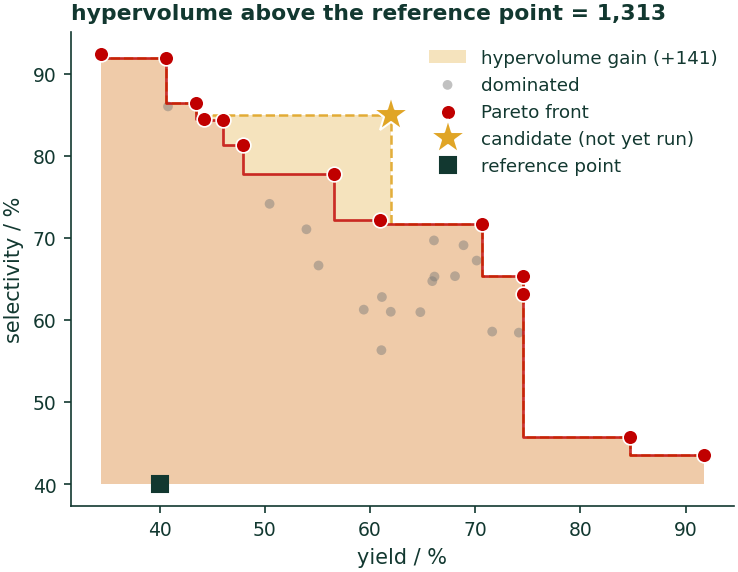

wrote ../lecture_12_figures/generated/fig_16_pareto_front.pdf
wrote ../lecture_12_figures/generated/fig_16_pareto_front.png


('../lecture_12_figures/generated/fig_16_pareto_front.pdf',
 '../lecture_12_figures/generated/fig_16_pareto_front.png')

In [2]:

rng = np.random.default_rng(4)
n = 30
u = rng.random((n, 2))
yield_ = 100 * (0.35 + 0.6 * np.exp(-((u[:, 0] - 0.7) ** 2) / 0.10)
                * (0.5 + 0.5 * u[:, 1])) + rng.normal(0, 2.0, n)
selec = 100 * (0.95 - 0.55 * np.exp(-((u[:, 0] - 0.75) ** 2) / 0.16)
               * (0.4 + 0.6 * u[:, 1])) + rng.normal(0, 2.0, n)
Y = np.column_stack([np.clip(yield_, 0, 100), np.clip(selec, 0, 100)])


def pareto(Y):
    keep = np.ones(len(Y), bool)
    for i in range(len(Y)):
        if keep[i]:
            dom = np.all(Y >= Y[i], axis=1) & np.any(Y > Y[i], axis=1)
            if dom.any():
                keep[i] = False
    return keep


def front_of(Y):
    keep = pareto(Y)
    order = np.argsort(Y[keep, 0])
    return Y[keep][order]


def hypervolume(F, ref):
    hv, prev_y = 0.0, ref[1]
    for px, py in F[::-1]:
        hv += max(px - ref[0], 0) * max(py - prev_y, 0)
        prev_y = max(prev_y, py)
    return hv


front = pareto(Y)
F = front_of(Y)
REF = np.array([40.0, 40.0])
hv = hypervolume(F, REF)

# a hypothetical new experiment, better than the current front -- this is
# exactly what EHVI scores: how much would running THIS condition grow the
# shaded area? Add it to the set and rebuild the front to find out.
NEW = np.array([62.0, 85.0])
F2 = front_of(np.vstack([Y, NEW]))
hv2 = hypervolume(F2, REF)
gain = hv2 - hv

fig, ax = plt.subplots(figsize=(5.7, 4.1))
# draw the extended (with-NEW) hypervolume first, in gold, then the current
# hypervolume on top, in red -- since the extended region always contains the
# current one, only the genuinely NEW area is left showing gold: that sliver
# *is* the hypervolume improvement
ax.fill_between(F2[:, 0], REF[1], F2[:, 1], step="pre", color=style.GOLD,
                alpha=0.30, lw=0, label=f"hypervolume gain (+{gain:,.0f})")
ax.step(F2[:, 0], F2[:, 1], where="pre", color=style.GOLD, lw=1.2, ls="--",
        alpha=0.9)
ax.fill_between(F[:, 0], REF[1], F[:, 1], step="pre", color=style.RED,
                alpha=0.10, lw=0)
# a Pareto point dominates everything down-and-left of it, so the boundary
# between two consecutive front points has to drop to the NEXT point's y
# right at the LEFT point's x (where="pre") -- not carry the left point's y
# rightward first (where="post", the earlier bug: that overstates the
# dominated region and bulges the wrong way, i.e. convex instead of concave)
ax.step(F[:, 0], F[:, 1], where="pre", color=style.RED, lw=1.3, alpha=0.8)

ax.scatter(Y[~front, 0], Y[~front, 1], s=22, c=style.GRAY, alpha=0.45,
           edgecolor="none", label="dominated")
ax.scatter(Y[front, 0], Y[front, 1], s=50, c=style.RED, edgecolor="white",
           linewidth=0.8, zorder=5, label="Pareto front")
ax.plot(*NEW, "*", ms=18, color=style.GOLD, mec="white", mew=1.0, zorder=6,
        label="candidate (not yet run)")
ax.plot(*REF, "s", ms=8, color=style.INK, label="reference point")

ax.set_xlabel("yield / %")
ax.set_ylabel("selectivity / %")
ax.set_title(f"hypervolume above the reference point = {hv:,.0f}", loc="left",
             fontsize=10.5)
ax.legend(loc="upper right", fontsize=8.8, framealpha=0.92,
          facecolor="white")
print("front size:", front.sum(), " hypervolume:", round(hv, 1),
      " with candidate:", round(hv2, 1), " gain:", round(gain, 1))
style.save(fig, "fig_16_pareto_front", OUT)